# 04 — Escalamiento y PCA

Se aplica escalamiento estándar sobre las variables numéricas del dataset procesado y luego PCA para explorar la estructura latente de los datos. Se documenta el propósito de cada decisión y se interpretan los resultados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('/content/streaming_users_clean (1).csv')
print(f"Dataset: {df.shape[0]} filas × {df.shape[1]} columnas")


Dataset: 8000 filas × 8 columnas


## Variables seleccionadas para PCA

Se utilizan las tres variables numéricas continuas disponibles: `age`, `monthly_watch_time_mins` y `customer_support_tickets`.

**Justificación:** Estas variables representan dimensiones independientes del perfil de usuario (demográfica, de consumo y de soporte). Se excluye `user_id` por ser un identificador sin significado analítico.

In [ ]:
num_cols= ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[num_cols].copy()
print(f"Variables seleccionadas:", num_cols)
X.head()

Variables seleccionadas: ['age', 'monthly_watch_time_mins', 'customer_support_tickets']


,age,monthly_watch_time_mins,customer_support_tickets
0,39.0,805.8,NaN
1,37.0,1173.4,2.0
2,28.0,401.0,0.0
3,43.0,62.4,0.0
4,51.0,477.8,1.0


## Varianza

In [ ]:
print("Varianza de cada variable:")
print(X.var().round(2))

Varianza de cada variable:
age                            131.23
monthly_watch_time_mins     185733.62
customer_support_tickets         0.81
dtype: float64


## Escalamiento — StandardScaler

**Justificación del escalamiento:** Las tres variables tienen escalas muy diferentes (edad en decenas, minutos en cientos, tickets en unidades). Sin escalamiento, el PCA estaría dominado por la variable con mayor varianza absoluta (`monthly_watch_time_mins`). StandardScaler centra en media 0 y desvío 1, garantizando que cada variable contribuya equitativamente.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

print("Varianza despues de estandarizar")
print(X_scaled_df.var().round(4))

print("Media despues de estandarizar")
print(X_scaled_df.mean().round(4))

Varianza despues de estandarizar
age                         1.0001
monthly_watch_time_mins     1.0001
customer_support_tickets    1.0001
dtype: float64
Media despues de estandarizar
age                        -0.0
monthly_watch_time_mins     0.0
customer_support_tickets   -0.0
dtype: float64


## Aplicación de PCA

In [ ]:
from sklearn.impute import SimpleImputer

pca = PCA()

# Imputar valores NaN en X_scaled antes de PCA
imputer = SimpleImputer(strategy='mean')
X_scaled_imputed = imputer.fit_transform(X_scaled)

X_pca = pca.fit_transform(X_scaled_imputed)

varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

print("Varianza explicada por componente:")
for i, (v, va) in enumerate(zip(varianza, varianza_acum)):
    print(f"  PC{i+1}: {v:.4f} ({v*100:.1f}%) | Acumulada: {va*100:.1f}%")

Varianza explicada por componente:
  PC1: 0.3382 (33.8%) | Acumulada: 33.8%
  PC2: 0.3323 (33.2%) | Acumulada: 67.0%
  PC3: 0.3296 (33.0%) | Acumulada: 100.0%


### Gráfico de varianza explicada (Scree plot)

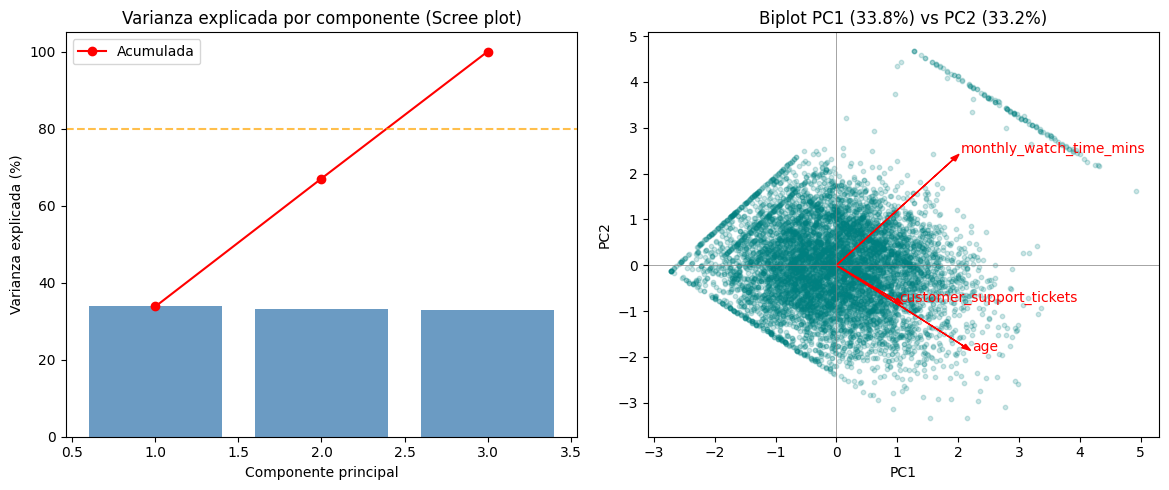

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
axes[0].bar(range(1, len(varianza)+1), varianza*100, color='steelblue', alpha=0.8)
axes[0].plot(range(1, len(varianza)+1), varianza_acum*100, 'ro-', label='Acumulada')
axes[0].set_title('Varianza explicada por componente (Scree plot)')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].legend()
axes[0].axhline(80, color='orange', linestyle='--', alpha=0.7, label='80%')

# Biplot (PC1 vs PC2)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2, s=10, color='teal')
for i, feat in enumerate(num_cols):
    axes[1].arrow(0, 0, pca.components_[0, i]*3, pca.components_[1, i]*3,
                  head_width=0.1, color='red')
    axes[1].text(pca.components_[0, i]*3.2, pca.components_[1, i]*3.2, feat, fontsize=10, color='red')
axes[1].set_title(f'Biplot PC1 ({varianza[0]*100:.1f}%) vs PC2 ({varianza[1]*100:.1f}%)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('../content/pca_plots.png', dpi=150)
plt.show()

## Cargas de las componentes

In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC1','PC2','PC3'], index = num_cols)
print("Cargas de cada variable en cada componente:")
print(loadings.round(3))


Cargas de cada variable en cada componente:
                            PC1    PC2    PC3
age                       0.697 -0.588 -0.411
monthly_watch_time_mins   0.639  0.769 -0.015
customer_support_tickets  0.325 -0.253  0.911


## Interpretación de los componentes

**PC1:** Esta componente explica el 33.8% de la varianza. Tiene cargas positivas significativas en `age` (0.697) y `monthly_watch_time_mins` (0.639), y una carga menor en `customer_support_tickets` (0.325). Esto sugiere que PC1 representa una dimensión de **'Nivel General de Compromiso'**, donde valores más altos indican usuarios con mayor edad y mayor tiempo de visualización mensual.

**PC2:** Esta componente explica el 33.2% de la varianza. Posee una carga muy alta y positiva en `monthly_watch_time_mins` (0.769) y una carga negativa significativa en `age` (-0.588). La variable `customer_support_tickets` tiene una carga negativa menor (-0.253). Esto indica que PC2 captura una diferenciación entre **'Jóvenes con Alto Consumo vs. Mayores con Bajo Consumo'**.

**PC3:** Esta componente explica el 33.0% de la varianza. Tiene una carga muy alta y positiva en `customer_support_tickets` (0.911) y una carga negativa moderada en `age` (-0.411). La carga de `monthly_watch_time_mins` es negligible (-0.015). Esta componente diferencia principalmente el **'Nivel de Interacción con Soporte'**, donde valores más altos se asocian con más tickets de soporte y ligeramente con usuarios más jóvenes.

## Matriz de correlación

                            age  monthly_watch_time_mins  \
age                       1.000                    0.008   
monthly_watch_time_mins   0.008                    1.000   
customer_support_tickets  0.007                    0.004   

                          customer_support_tickets  
age                                          0.007  
monthly_watch_time_mins                      0.004  
customer_support_tickets                     1.000  


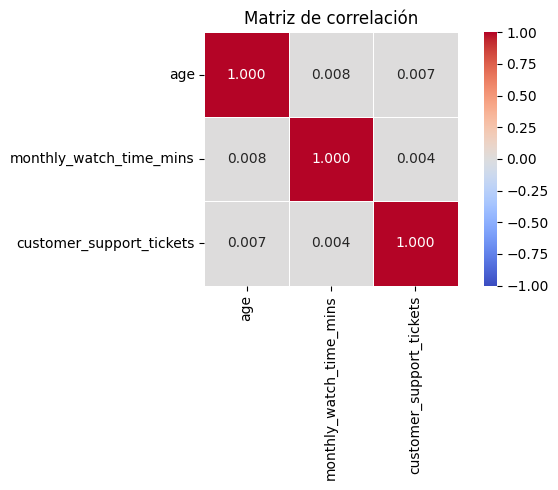

In [ ]:
import seaborn as sns
corr = df[num_cols].corr()
print(corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True,
            fmt='.3f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.tight_layout(); plt.show()

In [ ]:
# Número de componentes necesarios para explicar >= 80% de la varianza
n_80 = np.argmax(varianza_acum >= 0.80) + 1
print(f"Componentes necesarios para explicar >= 80% de la varianza: {n_80}")
print(f"Varianza explicada acumulada con {n_80} componentes: {varianza_acum[n_80-1]*100:.1f}%")


Componentes necesarios para explicar >= 80% de la varianza: 3
Varianza explicada acumulada con 3 componentes: 100.0%
